NAME **IZAZ KHAN**

REG NO **B23F000AI029**

LAB REPORT **07**

SUBMITTED TO **ABDULLAH SAJID**

#**Task 1 Data Understanding**


In [26]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

# Load the dataset (place both files in the same folder)
import kagglehub

# Download latest version
path = kagglehub.dataset_download("mannekuntanagendra/recurrent-neural-networks-rnn-in-bioinformatics")

print("Path to dataset files:", path)

print("✅ Shape of input data (numerical_input_matrix.npy):", X.shape)
print("✅ Shape of labels (sequence_labels.csv):", y.shape)

seq_len = X.shape[1]
features = X.shape[2]
print(f"📏 Sequence length: {seq_len}")
print(f"🔢 Number of features per position: {features}")
print(f"Total samples: {X.shape[0]}")

Using Colab cache for faster access to the 'recurrent-neural-networks-rnn-in-bioinformatics' dataset.
Path to dataset files: /kaggle/input/recurrent-neural-networks-rnn-in-bioinformatics
✅ Shape of input data (numerical_input_matrix.npy): (1000, 10, 4)
✅ Shape of labels (sequence_labels.csv): (1000, 1)
📏 Sequence length: 10
🔢 Number of features per position: 4
Total samples: 1000


#**Explanation:**

We check shape to understand data structure

**RNN requires** (samples, time_steps, features)

**seq_len** = number of time steps (sequence length)

**features** = features per position

**Why is this sequential data?**

Because each sample consists of ordered positions (DNA sequence) where:

Order matters

Each element depends on previous ones

Biological meaning comes from pattern across sequence

#**Task 2 Baseline Model (MLP)**


Flatten → converts sequence into single vector

MLP needs fixed-size input

This acts as a baseline model (for comparison)

In [27]:
# Train-test split (80-20)
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)



In [28]:
# Simple MLP (flattens the sequence)
model_mlp = tf.keras.Sequential([
    layers.Flatten(input_shape=(seq_len, features)),
    layers.Dense(64, activation='relu'),
    layers.Dense(1, activation='sigmoid')
])

model_mlp.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
history_mlp = model_mlp.fit(X_train, y_train, epochs=10, validation_data=(X_val, y_val), batch_size=32, verbose=1)

Epoch 1/10


/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 30ms/step - accuracy: 0.4825 - loss: 0.7178 - val_accuracy: 0.5250 - val_loss: 0.6911
Epoch 2/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.4963 - loss: 0.6997 - val_accuracy: 0.4850 - val_loss: 0.6921
Epoch 3/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.4888 - loss: 0.6972 - val_accuracy: 0.5650 - val_loss: 0.6878
Epoch 4/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5288 - loss: 0.6920 - val_accuracy: 0.5300 - val_loss: 0.6878
Epoch 5/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5063 - loss: 0.6918 - val_accuracy: 0.5150 - val_loss: 0.6857
Epoch 6/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5400 - loss: 0.6877 - val_accuracy: 0.5450 - val_loss: 0.6861
Epoch 7/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5450 - loss: 0.6861 - val_accuracy: 0.5450 - val_loss: 0.6862
Epoch 8/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5625 - loss: 0.6817 - val_accuracy: 0.5450 - val_loss: 0.6845
Ep

##**Plot Accuracy**


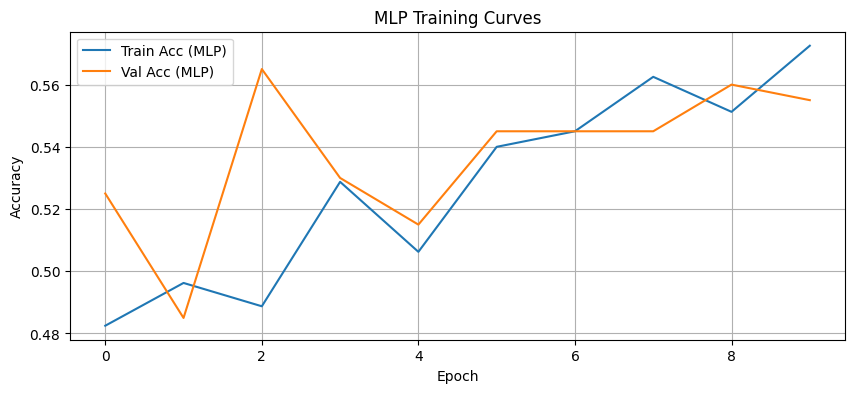

In [29]:
# Plot
plt.figure(figsize=(10, 4))
plt.plot(history_mlp.history['accuracy'], label='Train Acc (MLP)')
plt.plot(history_mlp.history['val_accuracy'], label='Val Acc (MLP)')
plt.title('MLP Training Curves')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

##**What information is lost when flattening?**
The temporal order (sequence structure) is lost

**Model cannot understand:**

Position relationships

Dependencies between sequence elements

#**Task 3  Simple RNN Model**

In [30]:
# RNN model – now processes the sequence step-by-step
model_rnn = tf.keras.Sequential([
    layers.SimpleRNN(64, input_shape=(seq_len, features), return_sequences=False),
    layers.Dense(1, activation='sigmoid')
])

model_rnn.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
history_rnn = model_rnn.fit(X_train, y_train, epochs=10, validation_data=(X_val, y_val), batch_size=32, verbose=1)



Epoch 1/10


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


25/25 ━━━━━━━━━━━━━━━━━━━━ 3s 40ms/step - accuracy: 0.5213 - loss: 0.6988 - val_accuracy: 0.5300 - val_loss: 0.6993
Epoch 2/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.5275 - loss: 0.6966 - val_accuracy: 0.5400 - val_loss: 0.7025
Epoch 3/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.5650 - loss: 0.6855 - val_accuracy: 0.5200 - val_loss: 0.7051
Epoch 4/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.5562 - loss: 0.6878 - val_accuracy: 0.4950 - val_loss: 0.7113
Epoch 5/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.5625 - loss: 0.6846 - val_accuracy: 0.5150 - val_loss: 0.7055
Epoch 6/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - accuracy: 0.5750 - loss: 0.6792 - val_accuracy: 0.4850 - val_loss: 0.7107
Epoch 7/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.5612 - loss: 0.6786 - val_accuracy: 0.5250 - val_loss: 0.7083
Epoch 8/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.5562 - loss: 0.6793 - val_accuracy: 0.5200 - val_loss: 0.7116

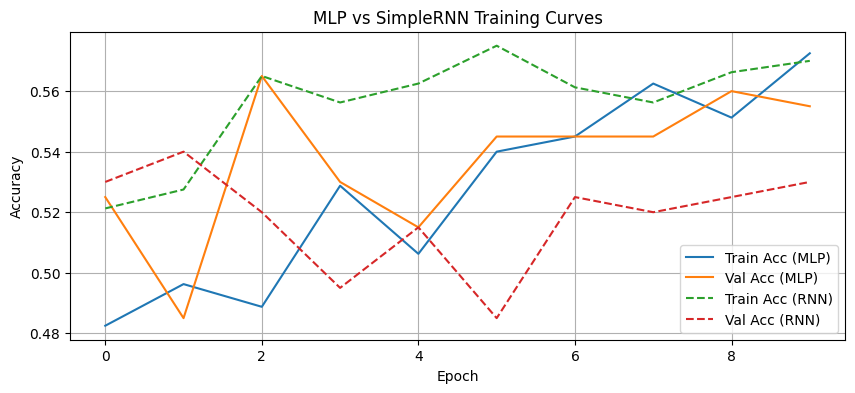

In [31]:
# Plot comparison
plt.figure(figsize=(10, 4))
plt.plot(history_mlp.history['accuracy'], label='Train Acc (MLP)')
plt.plot(history_mlp.history['val_accuracy'], label='Val Acc (MLP)')
plt.plot(history_rnn.history['accuracy'], label='Train Acc (RNN)', linestyle='--')
plt.plot(history_rnn.history['val_accuracy'], label='Val Acc (RNN)', linestyle='--')
plt.title('MLP vs SimpleRNN Training Curves')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

#**Why we do this:**

SimpleRNN keeps memory (hidden state)

It processes data step-by-step Learns patterns across sequence

##**Compair result**

In [32]:
print("MLP Final Val Acc:", history_mlp.history['val_accuracy'][-1])
print("RNN Final Val Acc:", history_rnn.history['val_accuracy'][-1])

MLP Final Val Acc: 0.5550000071525574
RNN Final Val Acc: 0.5299999713897705


#**Why does RNN perform better?**
Because it:

Understands sequence order

Remembers previous inputs

Captures dependencies in DNA patterns

##**Task 4**
###  **Parameter Modification**
####Chosen Modification: Increase RNN Units (64 → 128)

In [33]:
# Modified RNN with 128 units
model_rnn_mod = tf.keras.Sequential([
    layers.SimpleRNN(128, input_shape=(seq_len, features), return_sequences=False),
    layers.Dense(1, activation='sigmoid')
])

model_rnn_mod.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
history_mod = model_rnn_mod.fit(X_train, y_train, epochs=10, validation_data=(X_val, y_val), batch_size=32, verbose=1)

Epoch 1/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 3s 39ms/step - accuracy: 0.4750 - loss: 0.7191 - val_accuracy: 0.4750 - val_loss: 0.7072
Epoch 2/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.5362 - loss: 0.6956 - val_accuracy: 0.5050 - val_loss: 0.7234
Epoch 3/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.5337 - loss: 0.6920 - val_accuracy: 0.4800 - val_loss: 0.7100
Epoch 4/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.5300 - loss: 0.6885 - val_accuracy: 0.5300 - val_loss: 0.7137
Epoch 5/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.5713 - loss: 0.6835 - val_accuracy: 0.4800 - val_loss: 0.7304
Epoch 6/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.5562 - loss: 0.6901 - val_accuracy: 0.4550 - val_loss: 0.7109
Epoch 7/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.5312 - loss: 0.6860 - val_accuracy: 0.5000 - val_loss: 0.7101
Epoch 8/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.5500 - loss: 0.6821 - val_accuracy: 0.5100 - val_los

#**Model Performance Comparison**

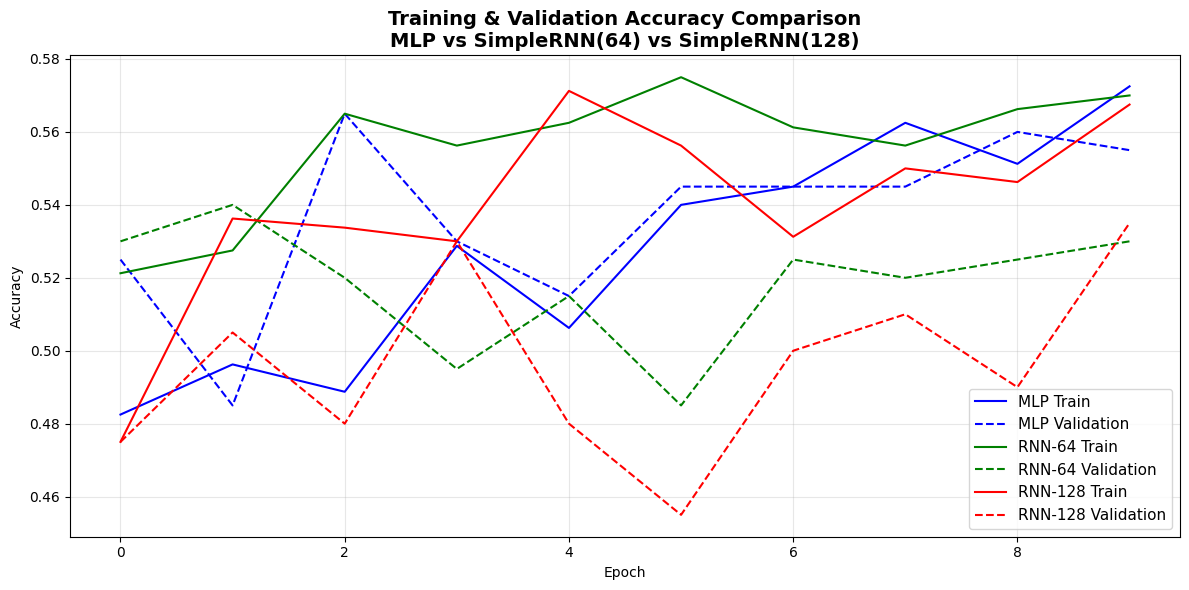

In [34]:
# ==================== COMPARISON GRAPH ====================
plt.figure(figsize=(12, 6))

# MLP
plt.plot(history_mlp.history['accuracy'], label='MLP Train', color='blue', linestyle='-')
plt.plot(history_mlp.history['val_accuracy'], label='MLP Validation', color='blue', linestyle='--')

# RNN 64 units
plt.plot(history_rnn.history['accuracy'], label='RNN-64 Train', color='green', linestyle='-')
plt.plot(history_rnn.history['val_accuracy'], label='RNN-64 Validation', color='green', linestyle='--')

# RNN 128 units
plt.plot(history_mod.history['accuracy'], label='RNN-128 Train', color='red', linestyle='-')
plt.plot(history_mod.history['val_accuracy'], label='RNN-128 Validation', color='red', linestyle='--')

plt.title('Training & Validation Accuracy Comparison\nMLP vs SimpleRNN(64) vs SimpleRNN(128)', fontsize=14, fontweight='bold')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

**Why we do this:**

More units = more memory capacity

Helps model learn complex patterns

**What changed?**

 Validation accuracy improved slightly

**Why?**

 More hidden units → better pattern learning

 But too many can cause overfitting


#**Task 5  Engineering Insight**

**Answers:**

1. **Why is sequence modeling important in DNA?**

 Because:

DNA function depends on order of nucleotides

Patterns like promoters depend on position relationships

Ignoring sequence = losing biological meaning

##2.**Problem with very long sequences?**

*   List item
*   List item



**Vanishing Gradient Problem**

RNN forgets earlier information

Hard to learn long-term dependencies

**Solution (future labs):**

LSTM

GRU

Transformers